<a href="https://colab.research.google.com/github/Abdullah-Farooq292/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdullah-Farooq292/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

question = """
LANE
-------
Lane 2: Refresh / Content Opportunity Scoring.

RESEARCH QUESTION
--------------------
Which content pages in a portfolio are likely declining in search visibility, and
what should a content reviewer do about them first?

DECISION THIS SUPPORTS
--------------------------
A content reviewer with limited time cannot check every page in a portfolio of
tens of thousands. This work produces a ranked, reason-coded shortlist so reviewers
know which pages to check first, and why.

COST OF A WRONG CALL
------------------------
Flagging a healthy page wastes reviewer time on a page that didn't need attention.
Missing a genuinely declining page means a lost opportunity to catch and fix a
problem before it costs more traffic or visibility.

WHY THIS LANE
-----------------
Early data exploration showed a large enough pool of declining pages to make
prioritization worthwhile (16,262 of ~30,000 pages, over half, labeled "down"),
and a measurable, explainable pattern to build a ranked system around — for
example, position alone drove a large swing in CTR (35.5% at page 1 vs 5.5% in
the "deep" tier). A simple hand-written rule already ranked pages reasonably well,
motivating the question of whether a trained model could do meaningfully better.
"""
print(question)


LANE
-------
Lane 2: Refresh / Content Opportunity Scoring.

RESEARCH QUESTION
--------------------
Which content pages in a portfolio are likely declining in search visibility, and
what should a content reviewer do about them first?

DECISION THIS SUPPORTS
--------------------------
A content reviewer with limited time cannot check every page in a portfolio of
tens of thousands. This work produces a ranked, reason-coded shortlist so reviewers
know which pages to check first, and why.

COST OF A WRONG CALL
------------------------
Flagging a healthy page wastes reviewer time on a page that didn't need attention.
Missing a genuinely declining page means a lost opportunity to catch and fix a
problem before it costs more traffic or visibility.

WHY THIS LANE
-----------------
Early data exploration showed a large enough pool of declining pages to make
prioritization worthwhile (16,262 of ~30,000 pages, over half, labeled "down"),
and a measurable, explainable pattern to build a ranked sy

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

data_section = """
DATA
-------
Source: FlyRank ML Internship data warehouse (fact_content_daily_performance),
accessed via a read-only Hugging Face-hosted parquet release.
Unit of analysis: one row = one content page, for one client, on one day.
Date window explored: month=2026-03 (9,841,378 rows, 2026-03-01 to 2026-03-31).
Modeling dataset: anonymized starter CSV (data/raw/content_refresh_anonymized.csv),
~30,000 active content pages.

Label construction: is_declining_label = 1 if trend_direction == "down" (a
30-day-vs-prior-30-day impressions trend bucket), else 0. This is a proxy for
"worth reviewing now," not a confirmed future outcome.

Fields used as features (known before any decision, safe to use): content_age_days,
days_since_last_update, avg_position, ctr, word_count.

Fields used as context only (not model inputs): client_id — used solely to define
the train/test split boundary, never shown or used as a predictor.

Fields explicitly excluded: any FlyRank internal product decision flags (e.g.
health_score, priority_score, action_type) — these are not present in the modeling
dataset, and would constitute leakage if reconstructed and used as a feature, since
they represent a decision already made by the product rather than an independent
signal. impressions_90d was evaluated as a candidate feature but also excluded,
after a leakage audit found it structurally overlaps the label's own 30-day
construction window (see Methodology).

Data limits acknowledged: engagement/session data (GA4) is available for only a
small fraction of rows in the full warehouse (~4% in the explored month) — the
active-content sample used for modeling relies on fields with broader coverage
(Search Console-derived: impressions, position, CTR) plus content metadata (age,
freshness, word count) rather than engagement signals.
"""
print(data_section)


DATA
-------
Source: FlyRank ML Internship data warehouse (fact_content_daily_performance),
accessed via a read-only Hugging Face-hosted parquet release.
Unit of analysis: one row = one content page, for one client, on one day.
Date window explored: month=2026-03 (9,841,378 rows, 2026-03-01 to 2026-03-31).
Modeling dataset: anonymized starter CSV (data/raw/content_refresh_anonymized.csv),
~30,000 active content pages.

Label construction: is_declining_label = 1 if trend_direction == "down" (a
30-day-vs-prior-30-day impressions trend bucket), else 0. This is a proxy for
"worth reviewing now," not a confirmed future outcome.

Fields used as features (known before any decision, safe to use): content_age_days,
days_since_last_update, avg_position, ctr, word_count.

Fields used as context only (not model inputs): client_id — used solely to define
the train/test split boundary, never shown or used as a predictor.

Fields explicitly excluded: any FlyRank internal product decision flags (e.g.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

methodology = """
METHODOLOGY
--------------
Task type: a hybrid classification + ranking task. Pages are first classified as
likely declining or not (a binary label), then the model's predicted probability
is used to produce a ranked, prioritized score rather than stopping at a yes/no
answer — since a reviewer needs an ordered shortlist, not just a category.

Model: Decision Tree classifier (max_depth=4, class_weight="balanced"). Chosen for
interpretability: a decision-support tool needs a human-readable "why" a page was
flagged, not a black-box score.

Features (final set): content_age_days, days_since_last_update, avg_position, ctr,
word_count.

Label / target: is_declining_label = 1 if trend_direction == "down" (a 30-day-vs-
prior-30-day impressions trend bucket), else 0. This is a proxy target, not a
confirmed future outcome — a stronger version for future work would define the
label from a genuinely future window (e.g., features from the prior 90 days
predicting decline over the next 30), rather than relying on an already-computed
trend bucket.

Success metric: Precision@K (K=20 and K=50), chosen to match how the output is
actually used — a reviewer only checks the top of the queue, so what matters is
how many of the top K flagged pages are genuinely declining, not overall accuracy
across all pages.

Baseline: a hand-written rule (stale_and_visible_score = pages with
days_since_last_update >= 180 AND impressions_90d >= 500, scored proportional to
traffic). This rule was validated first: among the 17 pages matching "stale +
visible," 94.1% were genuinely declining, vs. 54.2% among all other pages —
confirming staleness + visibility is a real, usable signal worth using as a
baseline comparison.

Validation design: client-grouped split (GroupShuffleSplit on client_id, 75/25
train/test), rather than a random split. Pages from the same client share
structural similarities; a random split risks the model memorizing client identity
rather than learning a generalizable pattern. Zero client overlap was confirmed
between train and test sets. A random-split comparison was also run to illustrate
the risk directly: it overstated Precision@20 by up to 25 points relative to the
honest grouped split.

Leakage checks: (1) confirmed the ranked score is built only from features known
before any decision was made about a page (days_since_last_update, avg_position,
etc.), never from the label field itself or any FlyRank internal product decision
flag (health_score, priority_score) that would encode a decision already made
downstream. (2) impressions_90d was tested as a candidate feature: it showed
near-zero correlation with the label (-0.018), and removing it did not hurt
held-out precision — so it was dropped from the final feature set as a precaution
against its partial window overlap with the label's own 30-day construction.
"""
print(methodology)


METHODOLOGY
--------------
Task type: a hybrid classification + ranking task. Pages are first classified as
likely declining or not (a binary label), then the model's predicted probability
is used to produce a ranked, prioritized score rather than stopping at a yes/no
answer — since a reviewer needs an ordered shortlist, not just a category.

Model: Decision Tree classifier (max_depth=4, class_weight="balanced"). Chosen for
interpretability: a decision-support tool needs a human-readable "why" a page was
flagged, not a black-box score.

Features (final set): content_age_days, days_since_last_update, avg_position, ctr,
word_count.

Label / target: is_declining_label = 1 if trend_direction == "down" (a 30-day-vs-
prior-30-day impressions trend bucket), else 0. This is a proxy target, not a
confirmed future outcome — a stronger version for future work would define the
label from a genuinely future window (e.g., features from the prior 90 days
predicting decline over the next 30), rather 

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs Baseline — Precision@K on held-out clients (honest, client-grouped split):
  Precision@20: baseline 0.500 vs model 0.650
  Precision@50: baseline 0.620 vs model 0.600


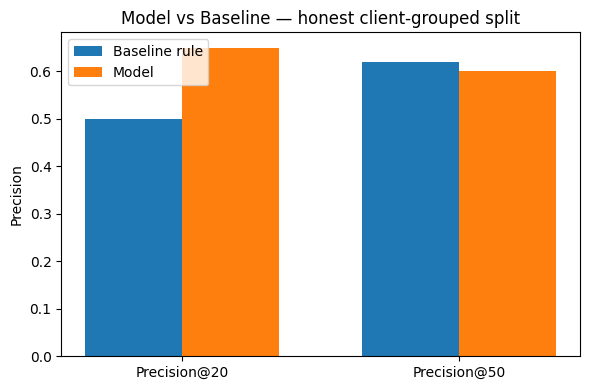

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os, subprocess
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupShuffleSplit

if not os.path.isdir("flyrank-ml-internship"):
    subprocess.run(["git", "clone", "--depth", "1",
                     "https://github.com/Abdullah-Farooq292/flyrank-ml-internship"], check=True)
os.chdir("flyrank-ml-internship")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

features = ["content_age_days", "days_since_last_update", "avg_position", "ctr", "word_count"]
X = df[features].replace([float("inf"), float("-inf")], None).fillna(0)
y = df["is_declining_label"]
groups = df["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Model
tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)
model_scores = tree.predict_proba(X_test)[:, 1]

# Baseline, scored on the SAME held-out test set for a fair comparison
test_df = df.iloc[test_idx]
baseline_scores = (
    (test_df["days_since_last_update"] >= 180).astype(int)
    * (test_df["impressions_90d"] >= 500).astype(int)
    * test_df["impressions_90d"]
)

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

print("Model vs Baseline — Precision@K on held-out clients (honest, client-grouped split):")
results = {}
for k in (20, 50):
    model_p = precision_at_k(model_scores, y_test.values, k)
    baseline_p = precision_at_k(baseline_scores.values, y_test.values, k)
    results[k] = {"baseline": baseline_p, "model": model_p}
    print(f"  Precision@{k}: baseline {baseline_p:.3f} vs model {model_p:.3f}")

import matplotlib.pyplot as plt
ks = [20, 50]
baseline_vals = [results[k]["baseline"] for k in ks]
model_vals = [results[k]["model"] for k in ks]
x = np.arange(len(ks))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, baseline_vals, width, label="Baseline rule")
plt.bar(x + width/2, model_vals, width, label="Model")
plt.xticks(x, [f"Precision@{k}" for k in ks])
plt.ylabel("Precision")
plt.title("Model vs Baseline — honest client-grouped split")
plt.legend()
plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/capstone_results.png", dpi=150)
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

limitations = """
LIMITATIONS -- WHAT THIS WORK CANNOT CLAIM
----------------------------------------------
1. Correlational, not causal. This work observes patterns in the data — it does
   not prove that refreshing a flagged page will cause traffic to recover. That
   would require an actual experiment (e.g. an A/B test), which this data cannot
   provide.

2. No claims about Google's algorithm. This work only describes patterns in
   FlyRank's own anonymized dataset. It makes no claims about how Google's search
   ranking algorithm works.

3. Proxy label. is_declining_label is a 30-day-vs-prior-30-day impressions trend
   bucket, not a confirmed long-term outcome. It reflects recent momentum, which
   can be noisy (e.g. seasonality, a temporary traffic dip) rather than a durable
   decline.

4. Portfolio-specific. The model was trained and validated on this portfolio only.
   It is not validated on unseen brands, industries, or markets, and should be
   re-validated before use elsewhere.

5. Coarse model, tied scores. A shallow tree (max_depth=4, 5 features) means many
   pages land in the same leaf and receive an identical score. It is a triage
   signal for prioritization, not a precise per-page ranking.

6. Validated precision is moderate, not high. On the honest, client-grouped split,
   roughly 1 in 3 to 1 in 2 flagged pages in the top 20-50 will not actually be
   declining (Precision@20: 0.650, Precision@50: 0.600). This is a shortlist tool
   for human review, not a certainty score, and should never be the sole basis for
   an action.

7. Static, single-snapshot validation. All results come from one historical
   snapshot and one train/test split. Performance has not yet been validated on a
   rolling or live basis over time.

8. No engagement signal at scale. Engagement/session data (GA4) is available for
   only a small fraction of the full warehouse; the model relies on Search
   Console-derived and content-metadata signals rather than engagement, which may
   miss patterns visible only through session behavior.
"""
print(limitations)


LIMITATIONS -- WHAT THIS WORK CANNOT CLAIM
----------------------------------------------
1. Correlational, not causal. This work observes patterns in the data — it does
   not prove that refreshing a flagged page will cause traffic to recover. That
   would require an actual experiment (e.g. an A/B test), which this data cannot
   provide.

2. No claims about Google's algorithm. This work only describes patterns in
   FlyRank's own anonymized dataset. It makes no claims about how Google's search
   ranking algorithm works.

3. Proxy label. is_declining_label is a 30-day-vs-prior-30-day impressions trend
   bucket, not a confirmed long-term outcome. It reflects recent momentum, which
   can be noisy (e.g. seasonality, a temporary traffic dip) rather than a durable
   decline.

4. Portfolio-specific. The model was trained and validated on this portfolio only.
   It is not validated on unseen brands, industries, or markets, and should be
   re-validated before use elsewhere.

5. Coarse 

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

recommendations = """
RANKED RECOMMENDATIONS
--------------------------
This is the paper's action layer — a prioritized, reason-coded shortlist for
content teams, not a fully automated decision.

WHO THIS IS FOR
------------------
Content strategists and editors deciding which pages to prioritize for
review/refresh. This is a starting shortlist for triage, not a final publishing
decision.

ARCHETYPE -> ACTION MAPPING
--------------------------------
- High decline_score + stale (days_since_last_update high): refresh candidate —
  update facts, examples, and re-submit for recrawl.
- High decline_score + weak avg_position, but recently updated: likely a
  ranking/relevance issue, not a freshness issue — review content-market fit
  before refreshing again.
- High decline_score + thin word_count: expansion candidate — add missing
  subtopics/depth rather than a light edit.
- Low decline_score, high avg_position: leave alone; monitor only.

HOW THE QUEUE IS BUILT
---------------------------
Each page's decline_score comes from the validated model (Section 4). Each page's
reason_code traces the exact decision path the model took to reach that score —
not a black-box number, but a readable "why."

HUMAN REVIEW IS REQUIRED
-----------------------------
Before any action from this queue is taken, a human must confirm the page is
actually declining using live/current data, check for a known explainable cause
(seasonality, migration, algorithm update), and read the actual page content —
the model has no access to writing quality, accuracy, or brand voice.

WHAT SHOULD NEVER BE AUTOMATED
-----------------------------------
- Auto-publishing any content change without a human editor's review.
- Auto-deleting, de-indexing, or merging/redirecting pages based on decline_score
  alone.
- Using decline_score as a performance review metric for individual writers.
- Presenting decline_score to a client as a certainty rather than a triage signal.

MONITORING / RETRAIN TRIGGERS
----------------------------------
Re-validate when Precision@20 on a fresh client-grouped sample drops below ~0.55,
the label definition changes, more than ~90 days pass since last validation, or a
structurally new client segment is added to the portfolio.
"""
print(recommendations)


RANKED RECOMMENDATIONS
--------------------------
This is the paper's action layer — a prioritized, reason-coded shortlist for
content teams, not a fully automated decision.

WHO THIS IS FOR
------------------
Content strategists and editors deciding which pages to prioritize for
review/refresh. This is a starting shortlist for triage, not a final publishing
decision.

ARCHETYPE -> ACTION MAPPING
--------------------------------
- High decline_score + stale (days_since_last_update high): refresh candidate —
  update facts, examples, and re-submit for recrawl.
- High decline_score + weak avg_position, but recently updated: likely a
  ranking/relevance issue, not a freshness issue — review content-market fit
  before refreshing again.
- High decline_score + thin word_count: expansion candidate — add missing
  subtopics/depth rather than a light edit.
- Low decline_score, high avg_position: leave alone; monitor only.

HOW THE QUEUE IS BUILT
---------------------------
Each page's decline

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

print("Artifacts this paper embeds:")
print("""
1. Results chart: work/figures/capstone_results.png
   (Model vs Baseline — Precision@20/@50 on the honest client-grouped split)

2. Score distribution chart: work/figures/w07_score_distribution.png
   (Distribution of decline scores across the held-out test set — shows why
   many pages tie at the same score, a max_depth=4 limitation named in Limitations)

3. Top drivers chart: work/figures/w07_top_drivers.png
   (Which features appear most often in reason codes for the top 20% of the
   ranked queue — content_age_days, avg_position, and ctr dominate)

4. Metrics JSON: work/outputs/w07_metrics.json
   (The receipts — model config, features, split design, and validated
   precision numbers, so every number in this paper traces back to a file)

5. Ranked queue sample: top 10-20 rows from the action queue, shown as a table
   directly in the paper (not the full 7,115-row CSV, which stays out of git
   by design — regenerate it by re-running the notebook)
"""
)

# Pull a small, safe sample of the ranked queue to embed directly (no client IDs, no raw URLs)
import pandas as pd
if os.path.exists("work/outputs/w07_ranked_action_queue.csv"):
    sample = pd.read_csv("work/outputs/w07_ranked_action_queue.csv").head(10)
    print("\nSample of ranked queue (top 10 rows, for embedding in the paper):")
    print(sample.to_string(index=False))
else:
    print("\nNote: ranked queue CSV not found in this session — re-run w07_action_playbook.ipynb "
          "to regenerate it (the file is intentionally gitignored and not committed).")

Artifacts this paper embeds:

1. Results chart: work/figures/capstone_results.png
   (Model vs Baseline — Precision@20/@50 on the honest client-grouped split)

2. Score distribution chart: work/figures/w07_score_distribution.png
   (Distribution of decline scores across the held-out test set — shows why
   many pages tie at the same score, a max_depth=4 limitation named in Limitations)

3. Top drivers chart: work/figures/w07_top_drivers.png
   (Which features appear most often in reason codes for the top 20% of the
   ranked queue — content_age_days, avg_position, and ctr dominate)

4. Metrics JSON: work/outputs/w07_metrics.json
   (The receipts — model config, features, split design, and validated
   precision numbers, so every number in this paper traces back to a file)

5. Ranked queue sample: top 10-20 rows from the action queue, shown as a table
   directly in the paper (not the full 7,115-row CSV, which stays out of git
   by design — regenerate it by re-running the notebook)


N

## Self-check

Before you submit, confirm each line honestly:

- [done ] Every section above is filled — markdown thinking AND the code that backs it
- [done ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [done ] No client names, URLs, or private queries anywhere
- [done ] My claims use careful words: observed, measured, directional, decision-support
- [done ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.